In [3]:
import numpy as np

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# data analysis project blinkit analysis

In [15]:
df = pd.read_csv(
    "C:\\Users\\Jagdish singh\\OneDrive\\Desktop\\mongo\\project blinkit analysis\\blinkit_data.csv"
)


In [ ]:
df


In [ ]:
df.head(3)

In [19]:
df.size

102276

In [20]:
df.shape

(8523, 12)

In [ ]:
df.describe()

In [ ]:
df.info

In [ ]:
df.columns

In [26]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [29]:
df["Sales"]=df["Sales"].astype(int) # changing data type

In [ ]:
df.Sales

In [34]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [ ]:
def func1(value):
    

In [39]:
df["Item Fat Content"]=df["Item Fat Content"].replace("LF","Low fat")
df["Item Fat Content"]=df["Item Fat Content"].replace("Low Fat","Low fat")
df["Item Fat Content"]=df["Item Fat Content"].replace("reg","Regular")

In [40]:
df["Item Fat Content"].unique()

array(['Regular', 'Low fat'], dtype=object)

In [ ]:
# bussineess requirements 

In [42]:
total_sales=df["Sales"].sum()
total_sales

np.int64(1197436)

In [44]:
average_sales =df["Sales"].mean()
average_sales

np.float64(140.4946615041652)

In [47]:
no_of_items=df["Sales"].count()
no_of_items

np.int64(8523)

In [48]:
average_rating=df['Rating'].mean()
average_rating

np.float64(3.965857092573038)

In [ ]:
# charts requirements 

In [91]:
df["Item Fat Content"].size

8523

In [50]:
# 1- total sales by fat content
sales_by_fat=df.groupby("Item Fat Content").size()
sales_by_fat

Item Fat Content
Low fat    5517
Regular    3006
dtype: int64

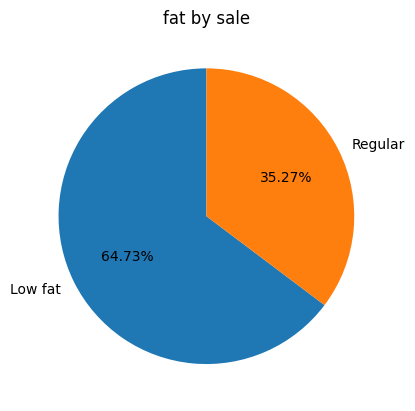

In [63]:
plt.pie(sales_by_fat , labels=sales_by_fat.index ,autopct="%1.2f%%" , startangle=90)
plt.title("fat by sale")
plt.show()

In [89]:
data1=df["Item Type"].unique()
data1

array(['Fruits and Vegetables', 'Health and Hygiene', 'Frozen Foods',
       'Canned', 'Soft Drinks', 'Household', 'Snack Foods', 'Meat',
       'Breads', 'Hard Drinks', 'Others', 'Dairy', 'Breakfast',
       'Baking Goods', 'Seafood', 'Starchy Foods'], dtype=object)

In [83]:
data2=df.groupby("Item Type").size()
data2

Item Type
Baking Goods              648
Breads                    251
Breakfast                 110
Canned                    649
Dairy                     682
Frozen Foods              856
Fruits and Vegetables    1232
Hard Drinks               214
Health and Hygiene        520
Household                 910
Meat                      425
Others                    169
Seafood                    64
Snack Foods              1200
Soft Drinks               445
Starchy Foods             148
dtype: int64

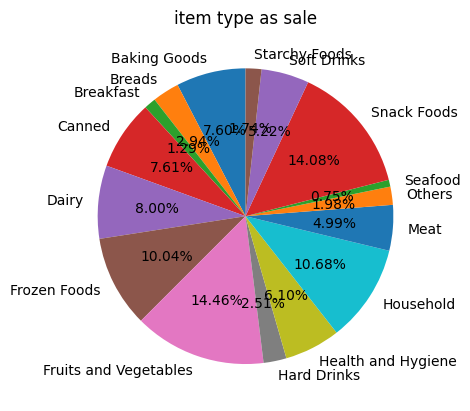

In [92]:
plt.pie(data2, labels = data2.index ,autopct="%1.2f%%" , startangle=90)
plt.title("item type as sale")
plt.show()

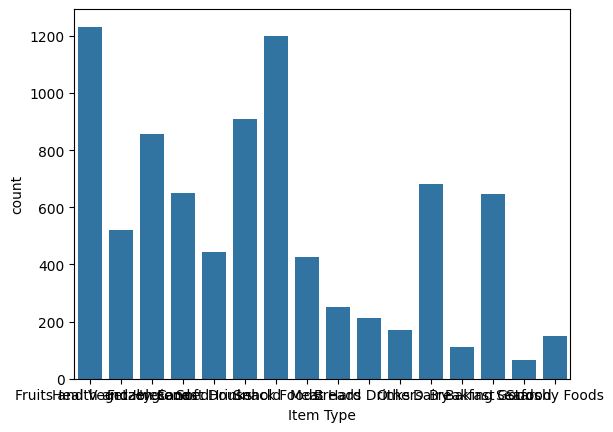

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Item Type", data=df)
plt.show()


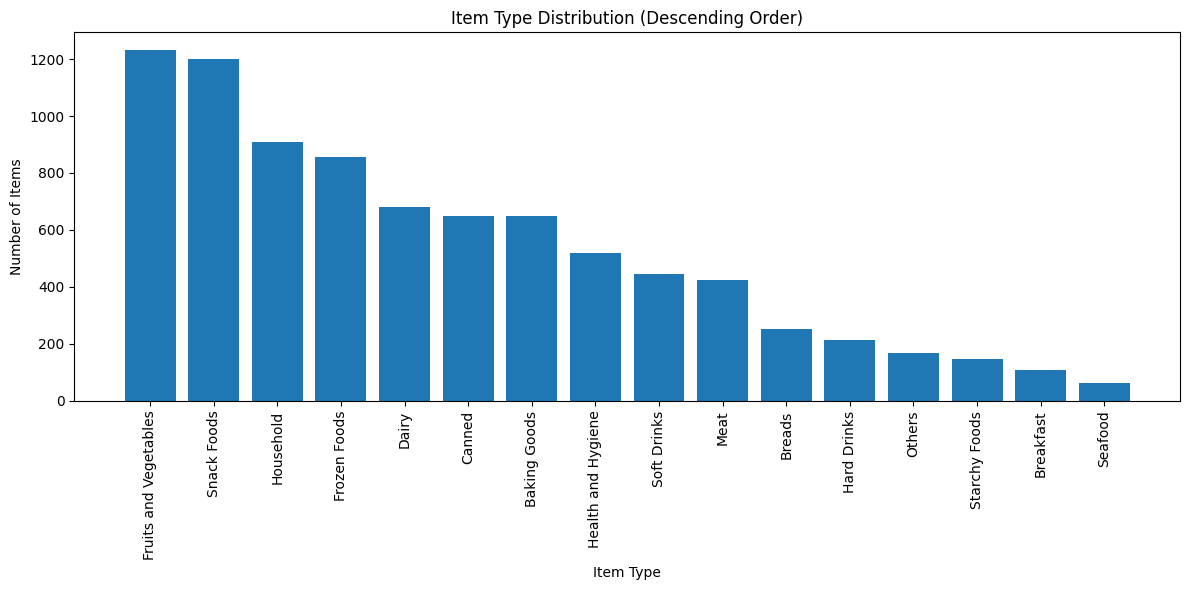

In [103]:
import matplotlib.pyplot as plt

# Count items per Item Type
data2 = df.groupby("Item Type").size()

# Sort values in descending order
data2_sorted = data2.sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar( data2_sorted.index ,data2_sorted.values)

# Formatting
plt.xticks(rotation=90)
plt.xlabel("Item Type")
plt.ylabel("Number of Items")
plt.title("Item Type Distribution (Descending Order)")

plt.tight_layout()
plt.show()


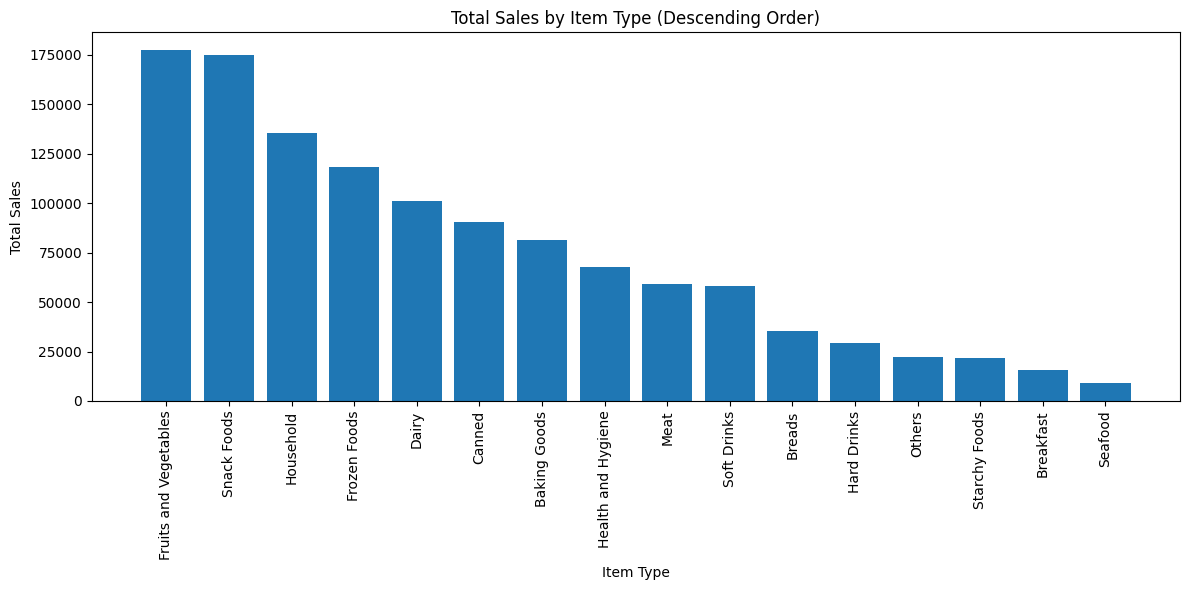

In [104]:
import matplotlib.pyplot as plt

# Group by Item Type and SUM sales
sales_by_item = df.groupby("Item Type")["Sales"].sum()

# Sort in descending order
sales_by_item_sorted = sales_by_item.sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(sales_by_item_sorted.index, sales_by_item_sorted.values)

# Formatting
plt.xticks(rotation=90)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Total Sales by Item Type (Descending Order)")

plt.tight_layout()
plt.show()


In [107]:
grouped=df.groupby(["Item Fat Content" , "Outlet Location Type"])["Sales"].sum()
grouped

Item Fat Content  Outlet Location Type
Low fat           Tier 1                  214280
                  Tier 2                  253572
                  Tier 3                  305728
Regular           Tier 1                  120927
                  Tier 2                  138193
                  Tier 3                  164736
Name: Sales, dtype: int64

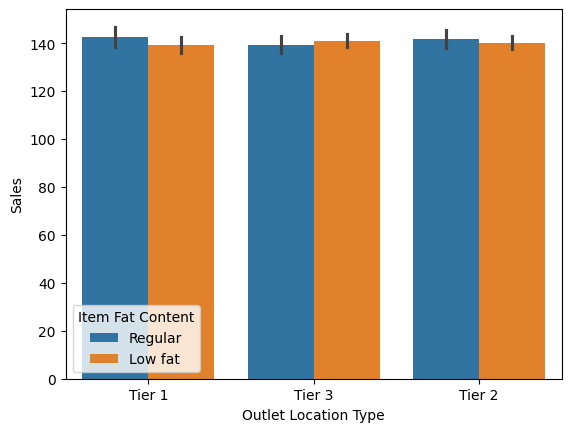

In [117]:
sns.barplot(x="Outlet Location Type",y="Sales", hue="Item Fat Content", data=df)
plt.show()

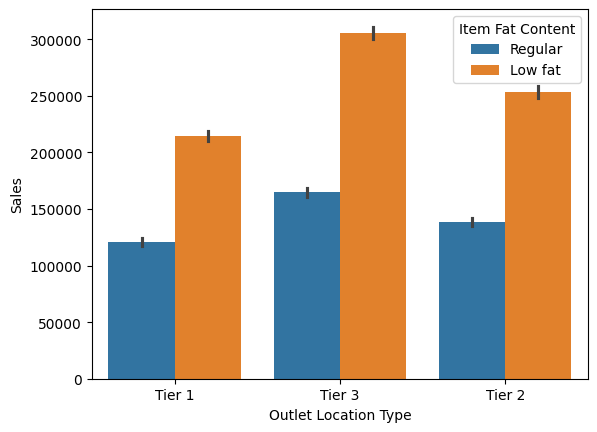

In [115]:
sns.barplot(
    x="Outlet Location Type",
    y="Sales",
    hue="Item Fat Content",
    data=df,
    estimator=sum
)
plt.show()


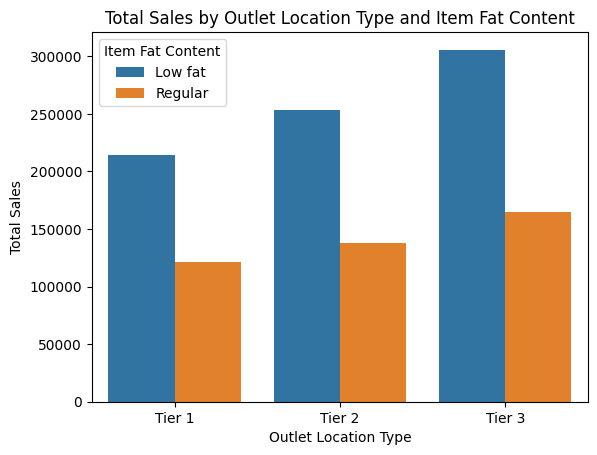

In [120]:
grouped_df = grouped.reset_index()

sns.barplot(
    data=grouped_df,
    x="Outlet Location Type",
    y="Sales",
    hue="Item Fat Content"
)

plt.title("Total Sales by Outlet Location Type and Item Fat Content")
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.show()


In [132]:
data3 =df.groupby("Outlet Establishment Year")["Sales"].sum()
data3

Outlet Establishment Year
1998    203779
2000    131338
2010    131649
2011     77865
2012    130015
2015    130474
2017    132651
2020    128640
2022    131025
Name: Sales, dtype: int64

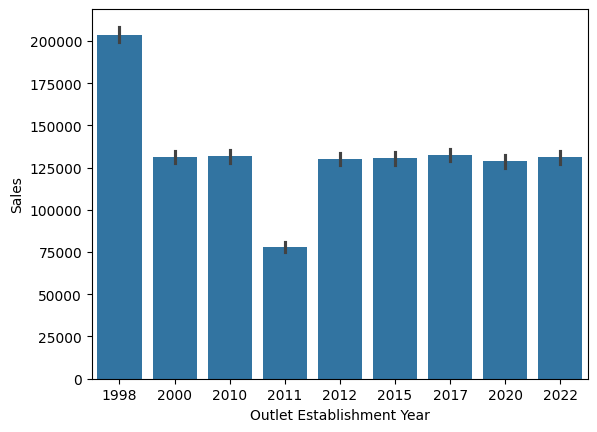

In [133]:
sns.barplot(x="Outlet Establishment Year",y="Sales", data =df , estimator=sum)
plt.show()

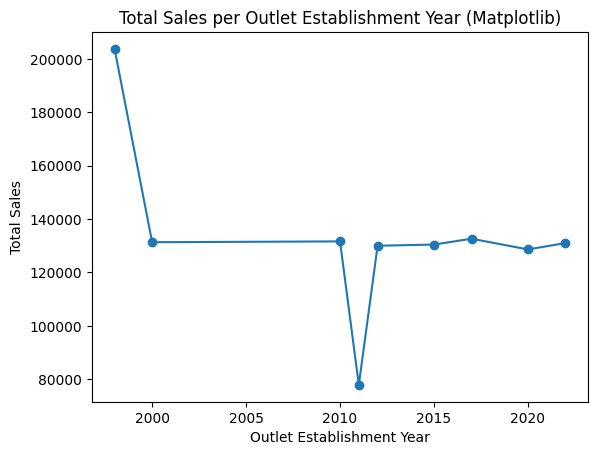

In [136]:
sales_per_year = df.groupby("Outlet Establishment Year")["Sales"].sum().reset_index()

plt.plot(sales_per_year["Outlet Establishment Year"], sales_per_year["Sales"], marker='o')
plt.title("Total Sales per Outlet Establishment Year (Matplotlib)")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.show()

In [137]:
sales_per_year = df.groupby("Outlet Establishment Year")["Sales"].sum().reset_index()
sales_per_year

,Outlet Establishment Year,Sales
0,1998,203779
1,2000,131338
2,2010,131649
3,2011,77865
4,2012,130015
5,2015,130474
6,2017,132651
7,2020,128640
8,2022,131025


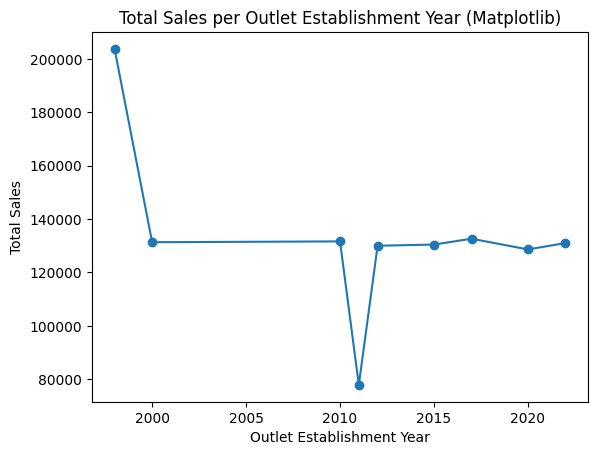

In [138]:
import matplotlib.pyplot as plt

# Aggregate sales per year
data3 = df.groupby("Outlet Establishment Year")["Sales"].sum()

# Matplotlib line plot using the Series
plt.plot(data3.index, data3.values, marker='o')
plt.title("Total Sales per Outlet Establishment Year (Matplotlib)")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.show()


In [144]:
data4=df.groupby("Outlet Size")["Sales"].sum()
data4

Outlet Size
High      248112
Medium    506088
Small     443236
Name: Sales, dtype: int64

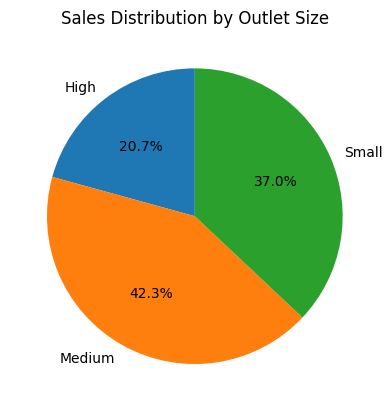

In [148]:
#plt.pie(data4.values,labels=data4.index, data=data4.values)
plt.pie(data4.values, labels=data4.index, autopct='%1.1f%%', startangle=90)
plt.title("Sales Distribution by Outlet Size")
plt.show()